In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('src')

clean_signals = np.load('data/simulated_clean/signals.npy')
noisy_signals = np.load('data/simulated_noisy/signals_noisy.npy')
wavelet_all   = np.load('data/processed/wavelet_denoised.npy')
savgol_all    = np.load('data/processed/savgol_denoised.npy')
auto_out      = np.load('data/processed/autoencoder_denoised.npy')
freq_axis     = np.load('data/simulated_clean/freq_axis.npy')

from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(noisy_signals, clean_signals, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test     = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Test clean  : {y_test.shape}")
print(f"Test noisy  : {X_test.shape}")
print(f"Autoencoder : {auto_out.shape}")

Test clean  : (150, 512)
Test noisy  : (150, 512)
Autoencoder : (150, 512)


In [3]:
def compute_snr(clean, denoised):
    signal_power = np.mean(clean ** 2)
    noise_power  = np.mean((clean - denoised) ** 2)
    return 10 * np.log10(signal_power / noise_power)

def compute_rmse(clean, denoised):
    return np.sqrt(np.mean((clean - denoised) ** 2))

methods = {
    'Noisy'         : X_test,
    'Wavelet'       : wavelet_all[:150],
    'Savitzky-Golay': savgol_all[:150],
    'Autoencoder'   : auto_out,
}

results = {}
for name, signals in methods.items():
    snrs  = [compute_snr(y_test[i],  signals[i]) for i in range(len(y_test))]
    rmses = [compute_rmse(y_test[i], signals[i]) for i in range(len(y_test))]
    results[name] = {
        'snr_mean'  : np.mean(snrs),
        'snr_std'   : np.std(snrs),
        'rmse_mean' : np.mean(rmses),
        'rmse_std'  : np.std(rmses),
    }

print(f"{'Method':<20} {'SNR (dB)':<20} {'RMSE':<20}")
print(f"{'-'*60}")
for name, r in results.items():
    print(f"{name:<20} {r['snr_mean']:.2f} ± {r['snr_std']:.2f}{'':>5} {r['rmse_mean']:.4f} ± {r['rmse_std']:.4f}")

Method               SNR (dB)             RMSE                
------------------------------------------------------------
Noisy                26.72 ± 0.25      0.0615 ± 0.0018
Wavelet              32.43 ± 0.79      0.0320 ± 0.0029
Savitzky-Golay       30.17 ± 0.44      0.0413 ± 0.0021
Autoencoder          36.40 ± 0.74      0.0202 ± 0.0017


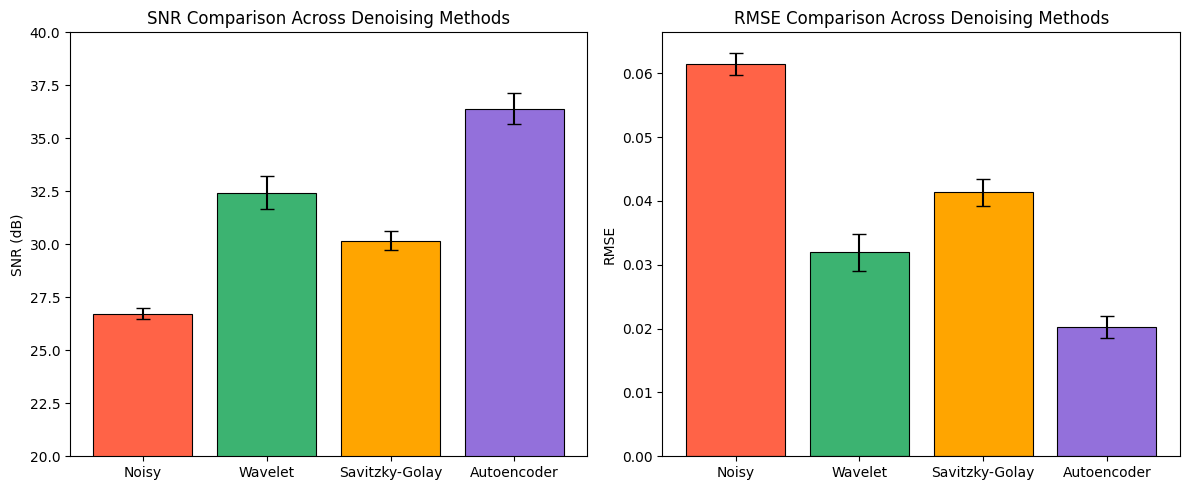

In [4]:
import csv

names     = list(results.keys())
snr_means = [results[n]['snr_mean'] for n in names]
snr_stds  = [results[n]['snr_std']  for n in names]
rmse_means= [results[n]['rmse_mean'] for n in names]
rmse_stds = [results[n]['rmse_std']  for n in names]
colors    = ['tomato', 'mediumseagreen', 'orange', 'mediumpurple']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(names, snr_means, yerr=snr_stds, color=colors, capsize=5, edgecolor='black', linewidth=0.8)
axes[0].set_title('SNR Comparison Across Denoising Methods')
axes[0].set_ylabel('SNR (dB)')
axes[0].set_ylim(20, 40)

axes[1].bar(names, rmse_means, yerr=rmse_stds, color=colors, capsize=5, edgecolor='black', linewidth=0.8)
axes[1].set_title('RMSE Comparison Across Denoising Methods')
axes[1].set_ylabel('RMSE')

plt.tight_layout()
plt.savefig('results/figures/05_metrics_comparison.png', dpi=150)
plt.show()

In [5]:
import csv

with open('results/metrics_summary.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Method', 'SNR_mean', 'SNR_std', 'RMSE_mean', 'RMSE_std'])
    for name, r in results.items():
        writer.writerow([name, f"{r['snr_mean']:.2f}", f"{r['snr_std']:.2f}",
                               f"{r['rmse_mean']:.4f}", f"{r['rmse_std']:.4f}"])

print("Saved to results/metrics_summary.csv")

Saved to results/metrics_summary.csv
